## OgunBiome Diversity Analysis
### Inulin Arm Community Composition

Visualising gut microbiota abundance shifts before and during inulin 
supplementation. Data source: Step 1 quality-checked output.

In [4]:
#Import packages
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import yaml
import os

In [7]:
# Set working directory explicitly to project root
os.chdir("/mnt/c/Users/oluwa/Desktop/MayTech/OgunBiome")

print(f"Working directory: {os.getcwd()}")

Working directory: /mnt/c/Users/oluwa/Desktop/MayTech/OgunBiome


### 1. Load Configuration and Data

In [8]:
with open("config/config.yaml", "r") as f:
    config = yaml.safe_load(f)

df = pd.read_csv("results/quality_check/data_summary.csv")

print(f"Taxa loaded: {df.shape[0]}")
print(f"Columns: {df.columns.tolist()}")

Taxa loaded: 30
Columns: ['Sequence', 'Classification', '% Abund. Before', '% Abund During', 'Fold Change', 'Num >1% increase', 'p-value', 'Adjusted p-value']


### 2. Before vs During Abundance — Full Community View

Horizontal bar chart comparing mean relative abundance of all 30 taxa 
at baseline and during inulin supplementation. Sorted by fold change 
so strongest responders appear at the top.

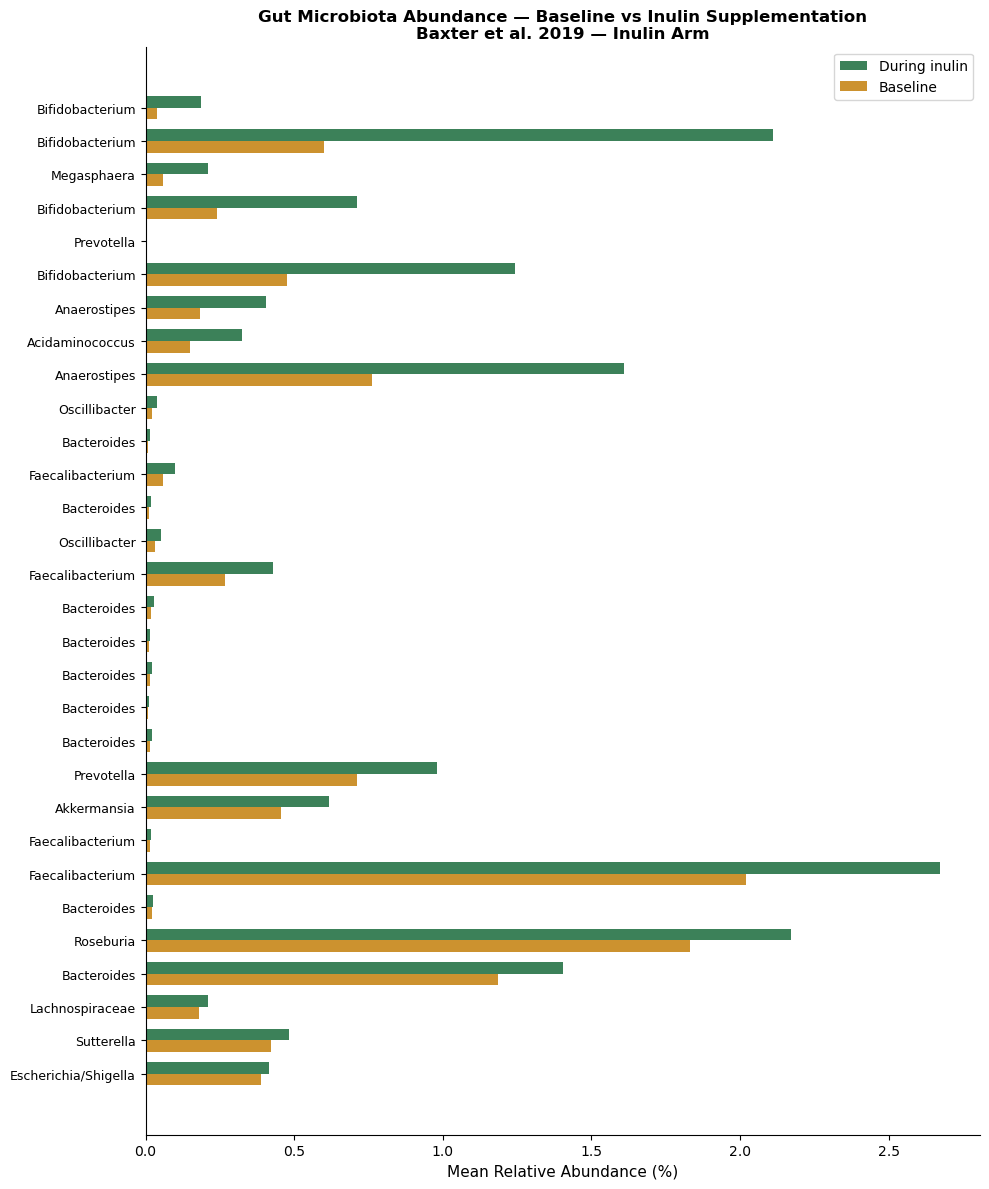

In [10]:
green = config["report"]["colors"]["green"]
gold = config["report"]["colors"]["gold"]

col_class = config["columns"]["classification"]
col_before = config["columns"]["abund_before"]
col_during = config["columns"]["abund_during"]
col_fc = config["columns"]["fold_change"]

df_sorted = df.sort_values(col_fc, ascending=True).copy()

labels = df_sorted[col_class].tolist()
before = df_sorted[col_before].tolist()
during = df_sorted[col_during].tolist()

y = np.arange(len(labels))
height = 0.35

fig, ax = plt.subplots(figsize=(10, 12))

ax.barh(y + height/2, during, height, color=green,
        label="During inulin", alpha=0.85)
ax.barh(y - height/2, before, height, color=gold,
        label="Baseline", alpha=0.85)

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel("Mean Relative Abundance (%)", fontsize=11)
ax.set_title(
    "Gut Microbiota Abundance — Baseline vs Inulin Supplementation\n"
    "Baxter et al. 2019 — Inulin Arm",
    fontsize=12, fontweight="bold"
)
ax.legend(fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("results/diversity/abundance_chart.png", 
            dpi=150, bbox_inches="tight")
plt.show()

### 3. Aggregate by Genus

Multiple OTU sequences map to the same genus. We aggregate by genus 
summing abundances to produce a clean genus-level community profile 
appropriate for client reporting.

In [11]:
col_class = config["columns"]["classification"]
col_before = config["columns"]["abund_before"]
col_during = config["columns"]["abund_during"]
col_fc = config["columns"]["fold_change"]
col_adjp = config["columns"]["adjusted_pvalue"]

df_genus = df.groupby(col_class).agg(
    abund_before=(col_before, "sum"),
    abund_during=(col_during, "sum"),
    fold_change=(col_fc, "mean"),
    adjusted_pvalue=(col_adjp, "min")
).reset_index()

print(f"Genera after aggregation: {df_genus.shape[0]}")
print(df_genus.sort_values("fold_change", ascending=False))

Genera after aggregation: 13
          Classification  abund_before  abund_during  fold_change  \
4        Bifidobacterium      1.352381      4.254762     3.540065   
8            Megasphaera      0.060204      0.209354     3.477401   
0        Acidaminococcus      0.149263      0.324376     2.173186   
2           Anaerostipes      0.943367      2.013549     2.162921   
10            Prevotella      0.713039      0.983503     2.133561   
9          Oscillibacter      0.052494      0.087982     1.683941   
6       Faecalibacterium      2.360488      3.218141     1.481193   
3            Bacteroides      1.293197      1.557200     1.436247   
1            Akkermansia      0.456859      0.617460     1.351532   
11             Roseburia      1.831009      2.171088     1.185733   
7        Lachnospiraceae      0.178912      0.208560     1.165716   
12            Sutterella      0.423243      0.482596     1.140236   
5   Escherichia/Shigella      0.389002      0.415590     1.068347   

    

In [13]:
df_genus.sort_values("fold_change", ascending=False).style.format({
    "abund_before": "{:.3f}",
    "abund_during": "{:.3f}",
    "fold_change": "{:.2f}",
    "adjusted_pvalue": "{:.4f}"
})
df_genus.to_csv("results/diversity/genus_abundance_summary.csv", index=False)
print("Saved: results/diversity/genus_abundance_summary.csv")

Saved: results/diversity/genus_abundance_summary.csv


In [16]:
pd.read_csv("results/diversity/genus_abundance_summary.csv")

,Classification,abund_before,abund_during,fold_change,adjusted_pvalue
0,Acidaminococcus,0.149263,0.324376,2.173186,0.742649
1,Akkermansia,0.456859,0.617460,1.351532,0.783971
2,Anaerostipes,0.943367,2.013549,2.162921,0.000130
3,Bacteroides,1.293197,1.557200,1.436247,0.742649
4,Bifidobacterium,1.352381,4.254762,3.540065,0.002175
5,Escherichia/Shigella,0.389002,0.415590,1.068347,0.742649
6,Faecalibacterium,2.360488,3.218141,1.481193,0.742649
7,Lachnospiraceae,0.178912,0.208560,1.165716,0.742649
8,Megasphaera,0.060204,0.209354,3.477401,0.742649
9,Oscillibacter,0.052494,0.087982,1.683941,0.266610


### 4. Top Responders — Significant Taxa

Bar chart showing the five statistically significant taxa ordered by 
fold change. FDR < 0.05. OgunBiome brand colours distinguish 
Bifidobacterium from Anaerostipes.

In [17]:
significant_genus = df_genus[
    df_genus["adjusted_pvalue"] < config["thresholds"]["fdr"]
].sort_values("fold_change", ascending=False).copy()

print(f"Significant genera: {len(significant_genus)}")
print(significant_genus[["Classification", "fold_change", "adjusted_pvalue"]])

Significant genera: 2
    Classification  fold_change  adjusted_pvalue
4  Bifidobacterium     3.540065         0.002175
2     Anaerostipes     2.162921         0.000130


### 5. Significant Genera — Before vs During Inulin

Grouped bar chart showing Bifidobacterium and Anaerostipes abundance 
at baseline and during inulin supplementation. Fold change annotated 
above each intervention bar. Both genera reached statistical 
significance at FDR < 0.05.

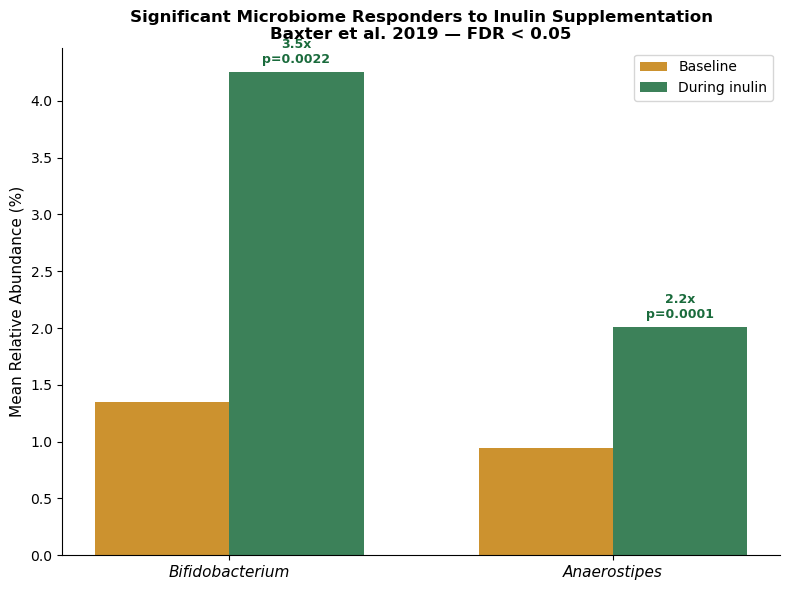

Saved: results/diversity/top_responders.png


In [18]:
green = config["report"]["colors"]["green"]
gold = config["report"]["colors"]["gold"]

genera = significant_genus["Classification"].tolist()
before = significant_genus["abund_before"].tolist()
during = significant_genus["abund_during"].tolist()
fold_changes = significant_genus["fold_change"].tolist()
pvalues = significant_genus["adjusted_pvalue"].tolist()

x = np.arange(len(genera))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))

bars_before = ax.bar(x - width/2, before, width,
                     color=gold, label="Baseline", alpha=0.85)
bars_during = ax.bar(x + width/2, during, width,
                     color=green, label="During inulin", alpha=0.85)

# Annotate fold change above each green bar
for bar, fc, p in zip(bars_during, fold_changes, pvalues):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f"{fc:.1f}x\np={p:.4f}",
        ha="center", va="bottom",
        fontsize=9, fontweight="bold", color=green
    )

ax.set_xticks(x)
ax.set_xticklabels(genera, fontsize=11, fontstyle="italic")
ax.set_ylabel("Mean Relative Abundance (%)", fontsize=11)
ax.set_title(
    "Significant Microbiome Responders to Inulin Supplementation\n"
    "Baxter et al. 2019 — FDR < 0.05",
    fontsize=12, fontweight="bold"
)
ax.legend(fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("results/diversity/top_responders.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/diversity/top_responders.png")

## Summary — Step 2 Diversity Analysis

### What Was Done
Gut microbiota abundance data from the Baxter et al. 2019 inulin 
intervention arm was visualised at the community level. Raw OTU-level 
data was aggregated to genus level producing a clean 13-genus community 
profile appropriate for client reporting.

### Key Findings
Two genera responded significantly to chicory-derived inulin 
supplementation at FDR < 0.05:

- **Bifidobacterium** — 3.5x fold increase (1.35% → 4.25%) — adj.p = 0.0022  
  The primary inulin fermenter. Selectively enriched through its 
  beta-fructosidase enzymatic capacity to degrade inulin's beta-2-1 
  fructose linkages.

- **Anaerostipes** — 2.2x fold increase (0.94% → 2.01%) — adj.p = 0.0001  
  The most statistically significant responder. A butyrate producer 
  that cross-feeds on acetate released by Bifidobacterium during 
  inulin fermentation — demonstrating the complete prebiotic 
  metabolic cascade operating in vivo.

### Biological Significance
The co-enrichment of Bifidobacterium and Anaerostipes confirms the 
inulin → Bifidobacterium → acetate → Anaerostipes → butyrate cascade. 
Butyrate is the primary energy source for colonocytes and a critical 
regulator of gut barrier integrity and mucosal immune function.

### Outputs Produced
- `results/diversity/abundance_chart.png` — full community view
- `results/diversity/top_responders.png` — significant genera chart  
- `results/diversity/genus_abundance_summary.csv` — aggregated genus table

### Next Step
Step 3 — Differential abundance analysis and volcano plot production.